In [1]:
# Use this initial code to work in the notebook as if it were a module, that 
# is, to be able to export classes and functions from other subpackages.

import os
import sys

package_path = os.path.abspath('.').split(os.sep + 'notebooks')[0]
if package_path not in sys.path:
    sys.path.append(package_path)

%load_ext autoreload
%autoreload 2

In [2]:
from thesis.utils import AbsolutePaths
import spectral
import numpy as np
from spectral import *
import matplotlib.pyplot as plt
import rasterio
import cv2
import matplotlib.patches as mpatches

# Load image

Shape of hyperspectral data: (3660, 3438, 379)
Number of bands: 379
wavelegths: [411.03182, 413.93909, 416.84635, 419.75362, 422.66089, 425.56816, 428.47543, 431.38269, 434.28996, 437.19723, 440.1045, 443.01177, 445.91904, 448.8263, 451.73357, 454.64084, 457.54811, 460.45538, 463.36264, 466.26991, 469.17718, 472.08445, 474.99172, 477.89898, 480.80625, 483.71352, 486.62079, 489.52806, 492.43533, 495.34259, 498.24986, 501.15713, 504.0644, 506.97167, 509.87894, 512.7862, 515.69347, 518.60074, 521.50801, 524.41528, 527.32254, 530.22981, 533.13708, 536.04435, 538.95162, 541.85889, 544.76615, 547.67342, 550.58069, 553.48796, 556.39523, 559.30249, 562.20976, 565.11703, 568.0243, 570.93157, 573.83883, 576.7461, 579.65337, 582.56064, 585.46791, 588.37517, 591.28244, 594.18971, 597.09698, 600.00425, 602.91152, 605.81878, 608.72605, 611.63332, 614.54059, 617.44786, 620.35512, 623.26239, 626.16966, 629.07693, 631.9842, 634.89147, 637.79873, 640.706, 643.61327, 646.52054, 649.42781, 652.33508, 655.

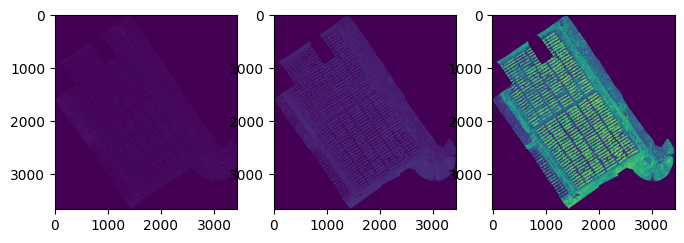

In [3]:
# Open the .hdr file (which automatically loads the .bsq data)
path_hdr_file = AbsolutePaths().get_abs_path_file('rionegro01_mosaic_geom_atm.hdr')
path_bsq_file = AbsolutePaths().get_abs_path_file('rionegro01_mosaic_geom_atm.bsq')

img = spectral.open_image(path_hdr_file)

# Access the wavelegths associated with each band
wavelegths = img.bands.centers

print('Shape of hyperspectral data:', img.shape)
print('Number of bands:', img.shape[2])
print('wavelegths:', wavelegths)

fig, ax = plt.subplots(1, 3, figsize=(8, 25))
ax = ax.flatten()

ind = wavelegths.index(463.36264)
ax[0].imshow(img[:, :, ind])

ind = wavelegths.index(559.30249)
ax[1].imshow(img[:, :, ind])

ind = wavelegths.index(745.36766)
ax[2].imshow(img[:, :, ind])

# Basic classificaion

## Crop image

In [4]:
img_cropped = img[700:1000, 500:800, :]
img_cropped.shape

(300, 300, 379)

Shape of hyperspectral data: (300, 300, 379)
Number of bands: 379
wavelegths: [411.03182, 413.93909, 416.84635, 419.75362, 422.66089, 425.56816, 428.47543, 431.38269, 434.28996, 437.19723, 440.1045, 443.01177, 445.91904, 448.8263, 451.73357, 454.64084, 457.54811, 460.45538, 463.36264, 466.26991, 469.17718, 472.08445, 474.99172, 477.89898, 480.80625, 483.71352, 486.62079, 489.52806, 492.43533, 495.34259, 498.24986, 501.15713, 504.0644, 506.97167, 509.87894, 512.7862, 515.69347, 518.60074, 521.50801, 524.41528, 527.32254, 530.22981, 533.13708, 536.04435, 538.95162, 541.85889, 544.76615, 547.67342, 550.58069, 553.48796, 556.39523, 559.30249, 562.20976, 565.11703, 568.0243, 570.93157, 573.83883, 576.7461, 579.65337, 582.56064, 585.46791, 588.37517, 591.28244, 594.18971, 597.09698, 600.00425, 602.91152, 605.81878, 608.72605, 611.63332, 614.54059, 617.44786, 620.35512, 623.26239, 626.16966, 629.07693, 631.9842, 634.89147, 637.79873, 640.706, 643.61327, 646.52054, 649.42781, 652.33508, 655.24

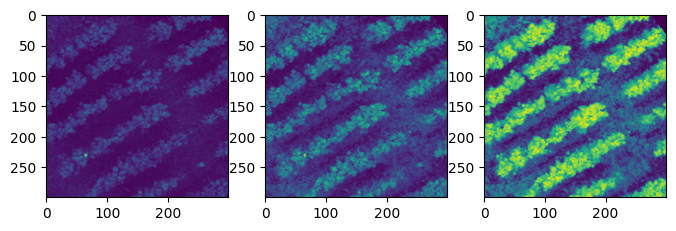

In [5]:
print('Shape of hyperspectral data:', img_cropped.shape)
print('Number of bands:', img_cropped.shape[2])
print('wavelegths:', wavelegths)

fig, ax = plt.subplots(1, 3, figsize=(8, 25))
ax = ax.flatten()

ind = wavelegths.index(463.36264)
ax[0].imshow(img_cropped[:, :, ind])

ind = wavelegths.index(559.30249)
ax[1].imshow(img_cropped[:, :, ind])

ind = wavelegths.index(745.36766)
ax[2].imshow(img_cropped[:, :, ind])

In [6]:
def scale_to_uint8(band):
    """Scales a single band to the 0-255 range and converts to uint8."""
    min_val = np.min(band)
    max_val = np.max(band)
    if max_val == min_val:
        scaled_band = np.zeros_like(band, dtype=np.uint8) + 127  # Avoid division by zero
    else:
        normalized_band = (band - min_val) / (max_val - min_val)
        scaled_band = (normalized_band * 255).astype(np.uint8)
    return scaled_band

ind_r = wavelegths.index(460.45538)
ind_g = wavelegths.index(547.67342)
ind_b = wavelegths.index(637.79873)

red_band, green_band, blue_band = img_cropped[:, :, ind_r], img_cropped[:, :, ind_g], img_cropped[:, :, ind_b]

scaled_red = scale_to_uint8(red_band)
scaled_green = scale_to_uint8(green_band)
scaled_blue = scale_to_uint8(blue_band)

print(f"Original data type: {scaled_red.dtype}, Min: {np.min(scaled_red):.4f}, Max: {np.max(scaled_red):.4f}")
print(f"Original data type: {scaled_green.dtype}, Min: {np.min(scaled_green):.4f}, Max: {np.max(scaled_green):.4f}")
print(f"Original data type: {scaled_blue.dtype}, Min: {np.min(scaled_blue):.4f}, Max: {np.max(scaled_blue):.4f}")

Original data type: uint8, Min: 0.0000, Max: 255.0000
Original data type: uint8, Min: 0.0000, Max: 255.0000
Original data type: uint8, Min: 0.0000, Max: 255.0000


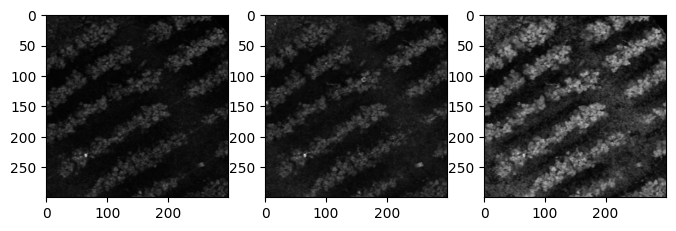

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(8, 10))
ax = ax.flatten()

rgb = cv2.cvtColor(scaled_red, cv2.COLOR_BGR2RGB)
ax[0].imshow(rgb, cmap = plt.cm.Spectral)

rgb = cv2.cvtColor(scaled_blue, cv2.COLOR_BGR2RGB)
ax[1].imshow(rgb, cmap = plt.cm.Spectral)

rgb = cv2.cvtColor(scaled_green, cv2.COLOR_BGR2RGB)
ax[2].imshow(rgb, cmap = plt.cm.Spectral)

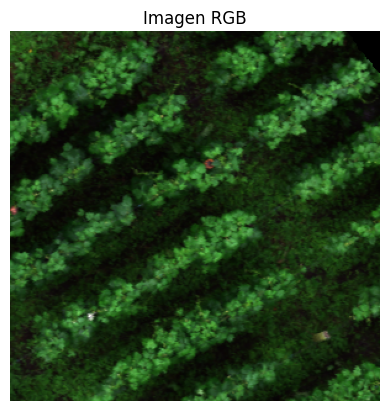

In [8]:
rgb_image = cv2.merge([scaled_blue, scaled_green, scaled_red])
# rgb_image = cv2.merge([scaled_red, scaled_green, scaled_blue])

# Muestra la imagen usando matplotlib
plt.imshow(rgb_image)
plt.title("Imagen RGB")
plt.axis('off')  # Para no mostrar los ejes
plt.show()

In [23]:
n_classes = 7

In [24]:
m, n, l = img_cropped.shape
m, n, l

(300, 300, 379)

In [25]:
sig = np.zeros((n_classes, l))
sig

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(7, 379))

In [26]:
# Generate 7 random positions in a 2D array of size (m, n)

np.random.seed(42)  # For reproducibility
coordinates = np.column_stack((np.random.randint(0, m, n_classes), np.random.randint(0, n, n_classes)))

for i, (x, y) in enumerate(coordinates):
    # x = int(x)
    # y = int(y)
    sig[i, :] = img_cropped[x, y, :]

coordinates

array([[102, 121],
       [270, 214],
       [106,  87],
       [ 71,  99],
       [188, 151],
       [ 20, 130],
       [102, 149]], dtype=int32)

In [27]:
# Spectral firm of random end members
sig

array([[0.002 , 0.0021, 0.0023, ..., 0.0156, 0.0159, 0.011 ],
       [0.0052, 0.0058, 0.0063, ..., 0.0224, 0.0225, 0.0222],
       [0.0036, 0.0034, 0.0034, ..., 0.0174, 0.0215, 0.0287],
       ...,
       [0.0043, 0.004 , 0.0038, ..., 0.0222, 0.0131, 0.007 ],
       [0.004 , 0.004 , 0.0038, ..., 0.032 , 0.0353, 0.0405],
       [0.005 , 0.0045, 0.0042, ..., 0.0103, 0.0156, 0.02  ]],
      shape=(7, 379))

In [28]:
sig = sig.T
sig.shape

(379, 7)

In [29]:
# Reshape the hyperspectral data for least squares calculation 
hcuben = img_cropped[:, :, :].reshape(m * n, l)

In [30]:
hcuben.shape

(90000, 379)

In [31]:
# class_names = ['class_1', 'class_2', 'class_3', 'class_4', 'class_5', 'class_6', 'class_7']
class_names = [f'class_{i+1}' for i in range(n_classes)]   
print(class_names)

['class_1', 'class_2', 'class_3', 'class_4', 'class_5', 'class_6', 'class_7']


In [32]:
# Estimate abundance fractions using least squares
abundance_map = np.linalg.lstsq(sig, hcuben.T, rcond=-1)[0]
abundance_map = abundance_map.T.reshape(m, n, n_classes)
abundance_map.shape

(300, 300, 7)

In [33]:
math_index = np.argmax(abundance_map, axis=2)
math_index

array([[1, 5, 5, ..., 4, 4, 4],
       [1, 1, 5, ..., 4, 4, 4],
       [5, 5, 5, ..., 4, 4, 4],
       ...,
       [5, 5, 1, ..., 4, 4, 4],
       [5, 1, 1, ..., 4, 4, 4],
       [5, 5, 5, ..., 4, 4, 4]], shape=(300, 300))

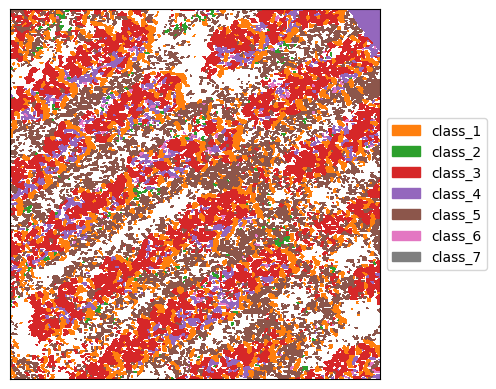

In [34]:
# Plot the abundance map
plt.figure()
for i in range(1, 8):
    plt.contourf(np.where(math_index == i, i, np.nan), levels=[i-0.5, i+0.5], colors=[plt.cm.tab10(i)])
plt.gca().set_aspect('equal', adjustable='box')
plt.gca().invert_yaxis()
plt.gca().set_xticks([])
plt.gca().set_yticks([])

# Create dummy patches for legend
legend_patches = [mpatches.Patch(color=plt.cm.tab10(i), label=class_names[i-1]) for i in range(1, len(class_names) + 1)]

# Display legend
plt.legend(handles=legend_patches, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()